# Emath 211: Numerical Methods
## Lab Title: Linear Algebra Applications - Interpolation

**Instructor:** Engr. Jamie Eduardo Rosal, MSCpE  
**Student Name:** *[Your Name]*  
**Student ID:** *[Your ID]*  
**Date of Submission:** *[Date]*

---

## 1. Objectives

- Apply polynomial interpolation to model engineering data.
- Formulate each interpolation task as a linear system \(A\mathbf{x}=\mathbf{b}\).
- Solve unknown polynomial coefficients using a direct method.
- Use the resulting model to estimate unknown engineering quantities.
- Compare interpolation and least-squares behavior for prediction.

## 2. Problem Statement (Given Data)

- **Problem 1 (Civil):** Bridge beam deflection at \((x,y)=(0,0), (10,-15), (20,0)\) in mm.
- **Problem 2 (Mechanical):** Lubricant viscosity at \((T,\mu)=(20,500), (40,250), (60,100)\) in mPa·s.
- **Problem 3 (Aerospace):** Drone altitude at \((t,h)=(1,50), (2,120), (3,250), (4,440)\).
- **Problem 4 (Electrical):** DAC samples \(V(0)=0.0\), \(V(1)=0.8\), \(V(2)=1.0\), \(V(3)=0.5\).
- **Problem 5 (Chemical):** Concentration data \((t,C)=(0,1.00), (5,0.60), (10,0.35)\).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(suppress=True, precision=6)

## 3. Problem 1 - Civil Engineering (Bridge Deformation)

### Mathematical Formulation
Assume a quadratic model:
\[
P(x)=ax^2+bx+c
\]
Using points \((0,0), (10,-15), (20,0)\):
\[
\begin{aligned}
a(0)^2+b(0)+c &= 0 \\
a(10)^2+b(10)+c &= -15 \\
a(20)^2+b(20)+c &= 0
\end{aligned}
\]
Matrix form:
\[
\underbrace{\begin{bmatrix}
0 & 0 & 1 \\
100 & 10 & 1 \\
400 & 20 & 1
\end{bmatrix}}_{A_1}
\underbrace{\begin{bmatrix}a\\b\\c\end{bmatrix}}_{\mathbf{x}}
=
\underbrace{\begin{bmatrix}0\\-15\\0\end{bmatrix}}_{\mathbf{b}_1}
\]
Direct method used in code: 
p.linalg.solve(A1, b1).

A1 =
 [[  0.   0.   1.]
 [100.  10.   1.]
 [400.  20.   1.]]
b1 = [  0. -15.   0.]
Coefficients: a=0.150000, b=-3.000000, c=0.000000
Estimated deflection at x=5 m: -11.2500 mm
Deflection at beam midpoint x=10 m: -15.0000 mm


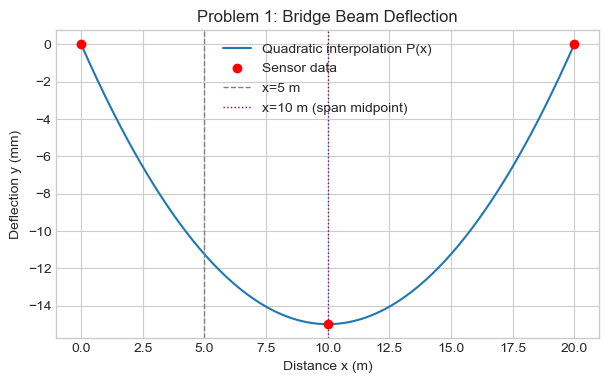

In [2]:
# Problem 1: Bridge deflection interpolation
x1 = np.array([0.0, 10.0, 20.0])
y1 = np.array([0.0, -15.0, 0.0])  # mm

A1 = np.vstack([x1**2, x1, np.ones_like(x1)]).T
coef1 = np.linalg.solve(A1, y1)  # [a, b, c]
a1, b1, c1 = coef1

def P1(x):
    return a1*x**2 + b1*x + c1

y_at_5 = P1(5.0)
y_at_10 = P1(10.0)  # actual span midpoint for 0..20 m

print("A1 =\n", A1)
print("b1 =", y1)
print(f"Coefficients: a={a1:.6f}, b={b1:.6f}, c={c1:.6f}")
print(f"Estimated deflection at x=5 m: {y_at_5:.4f} mm")
print(f"Deflection at beam midpoint x=10 m: {y_at_10:.4f} mm")

xx = np.linspace(0, 20, 300)
plt.figure(figsize=(7, 4))
plt.plot(xx, P1(xx), label="Quadratic interpolation P(x)", color="tab:blue")
plt.scatter(x1, y1, color="red", zorder=3, label="Sensor data")
plt.axvline(5, color="gray", ls="--", lw=1, label="x=5 m")
plt.axvline(10, color="purple", ls=":", lw=1, label="x=10 m (span midpoint)")
plt.xlabel("Distance x (m)")
plt.ylabel("Deflection y (mm)")
plt.title("Problem 1: Bridge Beam Deflection")
plt.legend()
plt.show()

## 4. Problem 2 - Mechanical Engineering (Thermodynamics)

### Mathematical Formulation
Use:
\[
p(T)=aT^2+bT+c
\]
From \((20,500), (40,250), (60,100)\):
\[
\underbrace{\begin{bmatrix}
20^2 & 20 & 1 \\
40^2 & 40 & 1 \\
60^2 & 60 & 1
\end{bmatrix}}_{A_2}
\begin{bmatrix}a\\b\\c\end{bmatrix}
=
\underbrace{\begin{bmatrix}500\\250\\100\end{bmatrix}}_{\mathbf{b}_2}
\]
Then evaluate \(p(50)\). For linear comparison on \([40,60]\), use two-point interpolation:
\[
\mu_{lin}(T)=\mu_{40}+\frac{\mu_{60}-\mu_{40}}{60-40}(T-40)
\]

A2 =
 [[ 400.   20.    1.]
 [1600.   40.    1.]
 [3600.   60.    1.]]
b2 = [500. 250. 100.]
Quadratic coefficients: a=0.125000, b=-20.000000, c=850.000000
Quadratic prediction at 50 C: 162.5000 mPa·s
Linear interpolation (40 to 60 C) at 50 C: 175.0000 mPa·s
Difference |quadratic - linear| at 50 C: 12.5000 mPa·s
Midpoint linear-error formula value: 12.5000 mPa·s


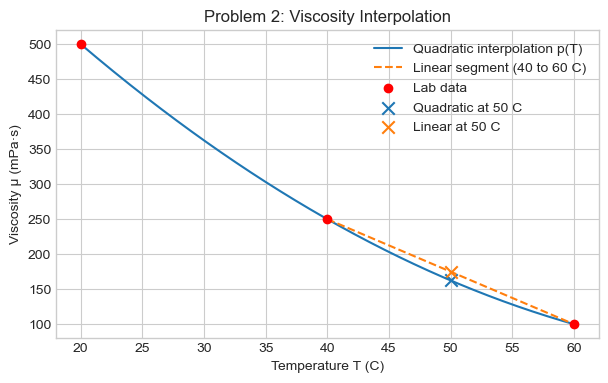

In [3]:
# Problem 2: Viscosity vs temperature
T = np.array([20.0, 40.0, 60.0])
mu = np.array([500.0, 250.0, 100.0])

A2 = np.vstack([T**2, T, np.ones_like(T)]).T
coef2 = np.linalg.solve(A2, mu)
a2, b2, c2 = coef2

def p2(temp):
    return a2*temp**2 + b2*temp + c2

mu_50_quad = p2(50.0)

# Linear interpolation only between 40 C and 60 C
T_low, T_high = 40.0, 60.0
mu_low, mu_high = 250.0, 100.0
slope_lin = (mu_high - mu_low) / (T_high - T_low)
mu_50_lin = mu_low + slope_lin * (50.0 - T_low)

# Theoretical midpoint error of linear interpolation for a quadratic
# |E_mid| = |f''| * h^2 / 8, where h = (x2-x1)
f2_second = 2*a2
h = T_high - T_low
linear_midpoint_error = abs(f2_second) * h**2 / 8

print("A2 =\n", A2)
print("b2 =", mu)
print(f"Quadratic coefficients: a={a2:.6f}, b={b2:.6f}, c={c2:.6f}")
print(f"Quadratic prediction at 50 C: {mu_50_quad:.4f} mPa·s")
print(f"Linear interpolation (40 to 60 C) at 50 C: {mu_50_lin:.4f} mPa·s")
print(f"Difference |quadratic - linear| at 50 C: {abs(mu_50_quad-mu_50_lin):.4f} mPa·s")
print(f"Midpoint linear-error formula value: {linear_midpoint_error:.4f} mPa·s")

TT = np.linspace(20, 60, 300)
plt.figure(figsize=(7, 4))
plt.plot(TT, p2(TT), label="Quadratic interpolation p(T)", color="tab:blue")
plt.plot([40, 60], [250, 100], "--", color="tab:orange", label="Linear segment (40 to 60 C)")
plt.scatter(T, mu, color="red", zorder=3, label="Lab data")
plt.scatter([50], [mu_50_quad], color="tab:blue", marker="x", s=80, label="Quadratic at 50 C")
plt.scatter([50], [mu_50_lin], color="tab:orange", marker="x", s=80, label="Linear at 50 C")
plt.xlabel("Temperature T (C)")
plt.ylabel("Viscosity μ (mPa·s)")
plt.title("Problem 2: Viscosity Interpolation")
plt.legend()
plt.show()

## 5. Problem 3 - Aerospace Engineering (Flight Path Reconstruction)

### Mathematical Formulation
Assume cubic form:
\[
h(t)=a_3 t^3 + a_2 t^2 + a_1 t + a_0
\]
Using data \((1,50), (2,120), (3,250), (4,440)\):
\[
\underbrace{\begin{bmatrix}
1^3 & 1^2 & 1 & 1 \\
2^3 & 2^2 & 2 & 1 \\
3^3 & 3^2 & 3 & 1 \\
4^3 & 4^2 & 4 & 1
\end{bmatrix}}_{A_3}
\underbrace{\begin{bmatrix}a_3\\a_2\\a_1\\a_0\end{bmatrix}}_{\mathbf{x}}
=
\underbrace{\begin{bmatrix}50\\120\\250\\440\end{bmatrix}}_{\mathbf{b}_3}
\]
Velocity is derivative:
\[
v(t)=h'(t)=3a_3 t^2 + 2a_2 t + a_1
\]
Evaluate at \(t=2.5\) s and \(t=3.73\) s.

A3 =
 [[ 1.  1.  1.  1.]
 [ 8.  4.  2.  1.]
 [27.  9.  3.  1.]
 [64. 16.  4.  1.]]
b3 = [ 50. 120. 250. 440.]
Cubic coefficients: a3=0.000000, a2=30.000000, a1=-20.000000, a0=40.000000
v(2.5 s)  = 130.0000 m/s
v(3.73 s) = 203.8000 m/s
Note: a3 is ~0, so the fitted cubic reduces to an exact quadratic.


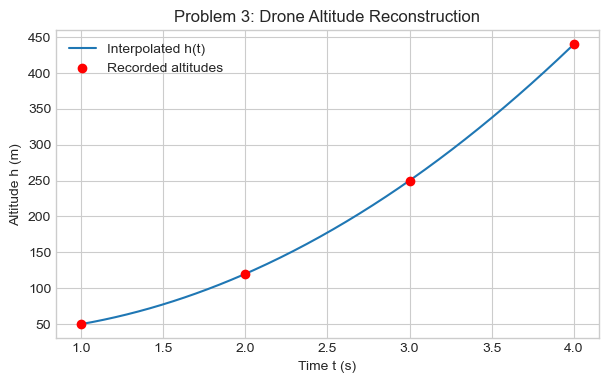

In [4]:
# Problem 3: Drone flight path reconstruction

t3 = np.array([1.0, 2.0, 3.0, 4.0])
h3 = np.array([50.0, 120.0, 250.0, 440.0])

A3 = np.vstack([t3**3, t3**2, t3, np.ones_like(t3)]).T
coef3 = np.linalg.solve(A3, h3)
a3, a2_3, a1_3, a0_3 = coef3

def h_poly(t):
    return a3*t**3 + a2_3*t**2 + a1_3*t + a0_3

def v_poly(t):
    return 3*a3*t**2 + 2*a2_3*t + a1_3

v_25 = v_poly(2.5)
v_373 = v_poly(3.73)

print("A3 =\n", A3)
print("b3 =", h3)
print(f"Cubic coefficients: a3={a3:.6f}, a2={a2_3:.6f}, a1={a1_3:.6f}, a0={a0_3:.6f}")
print(f"v(2.5 s)  = {v_25:.4f} m/s")
print(f"v(3.73 s) = {v_373:.4f} m/s")

if abs(a3) < 1e-12:
    print("Note: a3 is ~0, so the fitted cubic reduces to an exact quadratic.")

tt = np.linspace(1, 4, 300)
plt.figure(figsize=(7, 4))
plt.plot(tt, h_poly(tt), label="Interpolated h(t)", color="tab:blue")
plt.scatter(t3, h3, color="red", zorder=3, label="Recorded altitudes")
plt.xlabel("Time t (s)")
plt.ylabel("Altitude h (m)")
plt.title("Problem 3: Drone Altitude Reconstruction")
plt.legend()
plt.show()

## 6. Problem 4 - Electrical Engineering (Signal Processing)

### Mathematical Formulation (Lagrange Method)
Given nodes \((t_i,V_i)\) for \(i=0,1,2,3\), Lagrange interpolation is:
\[
V(t)=\sum_{i=0}^{3} V_i L_i(t), \qquad
L_i(t)=\prod_{\substack{j=0 \\ j\neq i}}^{3} \frac{t-t_j}{t_i-t_j}
\]
Use this to estimate \(V(1.5\text{ ms})\).

Expanded polynomial V(t):
          3        2
-0.01667 x - 0.25 x + 1.067 x
Estimated voltage at t=1.5 ms: 0.98125 V


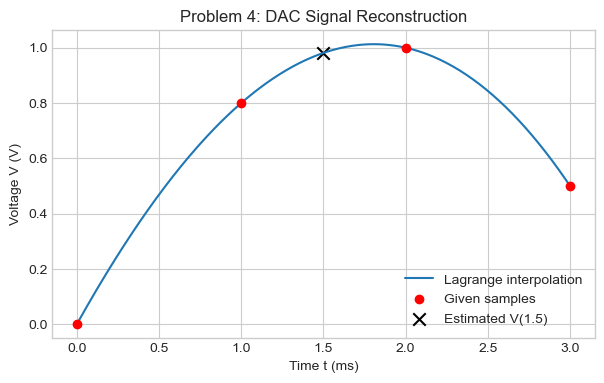

In [5]:
# Problem 4: Lagrange interpolation for voltage samples

t4 = np.array([0.0, 1.0, 2.0, 3.0])
V4 = np.array([0.0, 0.8, 1.0, 0.5])

def lagrange_eval(x_nodes, y_nodes, x):
    x = np.asarray(x, dtype=float)
    total = np.zeros_like(x, dtype=float)
    n = len(x_nodes)
    for i in range(n):
        term = np.ones_like(x, dtype=float)
        for j in range(n):
            if i != j:
                term *= (x - x_nodes[j]) / (x_nodes[i] - x_nodes[j])
        total += y_nodes[i] * term
    return total

# Build expanded polynomial using poly1d basis products
poly4 = np.poly1d([0.0])
for i in range(len(t4)):
    basis = np.poly1d([1.0])
    denom = 1.0
    for j in range(len(t4)):
        if i != j:
            basis *= np.poly1d([1.0, -t4[j]])
            denom *= (t4[i] - t4[j])
    poly4 += V4[i] * basis / denom

V_15 = lagrange_eval(t4, V4, np.array([1.5]))[0]

print("Expanded polynomial V(t):")
print(poly4)
print(f"Estimated voltage at t=1.5 ms: {V_15:.5f} V")

t_plot = np.linspace(0, 3, 300)
plt.figure(figsize=(7, 4))
plt.plot(t_plot, lagrange_eval(t4, V4, t_plot), label="Lagrange interpolation", color="tab:blue")
plt.scatter(t4, V4, color="red", zorder=3, label="Given samples")
plt.scatter([1.5], [V_15], color="black", marker="x", s=80, label="Estimated V(1.5)")
plt.xlabel("Time t (ms)")
plt.ylabel("Voltage V (V)")
plt.title("Problem 4: DAC Signal Reconstruction")
plt.legend()
plt.show()

### Runge's Phenomenon Note
High-degree polynomial interpolation on evenly spaced points can oscillate strongly near interval endpoints.  
This endpoint oscillation can create artificial peaks or dips (ringing), especially when the true signal is smooth (like sine).  
In signal work, piecewise interpolation (e.g., splines) is usually more stable than one global high-degree polynomial.

## 7. Problem 5 - Chemical Engineering (Reaction Rates)

### Mathematical Formulation
Use quadratic interpolation:
\[
C(t)=at^2+bt+c
\]
From data \((0,1.00), (5,0.60), (10,0.35)\):
\[
\underbrace{\begin{bmatrix}
0^2 & 0 & 1 \\
5^2 & 5 & 1 \\
10^2 & 10 & 1
\end{bmatrix}}_{A_5}
\underbrace{\begin{bmatrix}a\\b\\c\end{bmatrix}}_{\mathbf{x}}
=
\underbrace{\begin{bmatrix}1.00\\0.60\\0.35\end{bmatrix}}_{\mathbf{b}_5}
\]
To find when concentration reaches 0.50 mol/L, solve:
\[
C(t)-0.50=0
\]
Least-squares linear model for comparison:
\[
C_{LS}(t)=mt+b, \qquad
\begin{bmatrix}
t_1 & 1 \\
t_2 & 1 \\
t_3 & 1
\end{bmatrix}
\begin{bmatrix}m\\b\end{bmatrix}
\approx
\begin{bmatrix}C_1\\C_2\\C_3\end{bmatrix}
\]

A5 =
 [[  0.   0.   1.]
 [ 25.   5.   1.]
 [100.  10.   1.]]
b5 = [1.   0.6  0.35]
Interpolating coefficients: a=0.003000, b=-0.095000, c=1.000000
Roots of C(t)-0.50 = 0: [ 6.666667 25.      ]
Estimated stop time near data range: t = 6.6667 min
Least-squares line: C_ls(t) = (-0.065000)t + (0.975000)
Predicted C(20) from interpolation: 0.3000 mol/L
Predicted C(20) from least squares line: -0.3250 mol/L


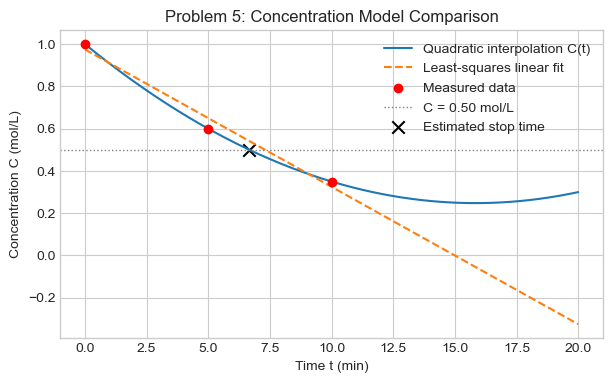

In [6]:
# Problem 5: Reaction concentration interpolation + least-squares comparison

t5 = np.array([0.0, 5.0, 10.0])
C5 = np.array([1.00, 0.60, 0.35])

A5 = np.vstack([t5**2, t5, np.ones_like(t5)]).T
coef5 = np.linalg.solve(A5, C5)
a5, b5, c5 = coef5

def C_interp(t):
    return a5*t**2 + b5*t + c5

# Solve C(t)=0.50
roots = np.roots([a5, b5, c5 - 0.50])
real_roots = roots[np.isreal(roots)].real
real_roots = np.sort(real_roots)

# pick physical root in measured interval [0,10], if present
candidate = real_roots[(real_roots >= 0) & (real_roots <= 10)]
t_stop = candidate[0] if len(candidate) > 0 else real_roots[0]

# Least-squares linear fit: C = m t + b
A_ls = np.vstack([t5, np.ones_like(t5)]).T
m_ls, b_ls = np.linalg.lstsq(A_ls, C5, rcond=None)[0]

def C_ls(t):
    return m_ls*t + b_ls

C20_interp = C_interp(20.0)
C20_ls = C_ls(20.0)

print("A5 =\n", A5)
print("b5 =", C5)
print(f"Interpolating coefficients: a={a5:.6f}, b={b5:.6f}, c={c5:.6f}")
print(f"Roots of C(t)-0.50 = 0: {real_roots}")
print(f"Estimated stop time near data range: t = {t_stop:.4f} min")
print(f"Least-squares line: C_ls(t) = ({m_ls:.6f})t + ({b_ls:.6f})")
print(f"Predicted C(20) from interpolation: {C20_interp:.4f} mol/L")
print(f"Predicted C(20) from least squares line: {C20_ls:.4f} mol/L")

tt5 = np.linspace(0, 20, 300)
plt.figure(figsize=(7, 4))
plt.plot(tt5, C_interp(tt5), label="Quadratic interpolation C(t)", color="tab:blue")
plt.plot(tt5, C_ls(tt5), "--", label="Least-squares linear fit", color="tab:orange")
plt.scatter(t5, C5, color="red", zorder=3, label="Measured data")
plt.axhline(0.50, color="gray", ls=":", lw=1, label="C = 0.50 mol/L")
plt.scatter([t_stop], [0.50], color="black", marker="x", s=80, label="Estimated stop time")
plt.xlabel("Time t (min)")
plt.ylabel("Concentration C (mol/L)")
plt.title("Problem 5: Concentration Model Comparison")
plt.legend()
plt.show()

## 8. Results, Discussion, and Conclusion

### Key Numerical Results
- **Problem 1:** \(P(x)=0.15x^2-3x\), so \(P(5)=-11.25\) mm.
- **Problem 2:** \(p(T)=0.125T^2-20T+850\), so \(p(50)=162.5\) mPa·s.
  Linear interpolation from 40 C to 60 C gives 175 mPa·s at 50 C, differing by 12.5 mPa·s.
- **Problem 3:** Solved coefficients give \(a_3=0\), \(a_2=30\), \(a_1=-20\), \(a_0=40\), so
  \(h(t)=30t^2-20t+40\) and \(v(t)=60t-20\).
  Hence \(v(2.5)=130\) m/s and \(v(3.73)=203.8\) m/s.
- **Problem 4:** Lagrange polynomial estimate at 1.5 ms is \(V(1.5)=0.98125\) V.
- **Problem 5:** \(C(t)=0.003t^2-0.095t+1\). Solving \(C(t)=0.50\) gives roots
  \(t\approx 6.667\) min and \(t=25\) min; practical stop time is \(t\approx 6.667\) min.

### Engineering Interpretation
- Interpolation passes exactly through given data, making it ideal for in-range estimation.
- For **Problem 2**, the data shows curvature, so quadratic interpolation captures trend better than a straight line.
- For **Problem 5**, both interpolation and least-squares are extrapolated at 20 min. The linear fit can become negative
  (non-physical), while the quadratic remains positive but still may become physically unrealistic outside the measured range.

### Limitation
- High-order global polynomials may oscillate (Runge's Phenomenon), especially near interval endpoints.
- For long-range prediction in physical systems, domain-based models (e.g., exponential kinetics, splines, or regression with physics constraints) are usually more reliable than pure interpolation.